# Supplemental Figure 4 Event Summary

Explore PFAM-supported transcripts, alternative splicing events in the final 300 nt, and evaluate cDNA tail uniqueness within promoter groups.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "Sup_Figure_4").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
else:
    PROJECT_ROOT = NOTEBOOK_DIR.parent
MODULE_ROOT = PROJECT_ROOT / "Sup_Figure_4"
DATA_DIR = MODULE_ROOT / "data_files"
FIGURE_DIR = MODULE_ROOT / "figure_files"
TOOLS_DIR = MODULE_ROOT / "tools"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TOOLS_DIR.mkdir(parents=True, exist_ok=True)

for candidate in {PROJECT_ROOT, MODULE_ROOT}:
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Tools directory: {TOOLS_DIR}")


Notebook directory: /Users/alvarens/Downloads/Sup_Figure_4
Project root: /Users/alvarens/Downloads
Data directory: /Users/alvarens/Downloads/Sup_Figure_4/data_files
Figure directory: /Users/alvarens/Downloads/Sup_Figure_4/figure_files
Tools directory: /Users/alvarens/Downloads/Sup_Figure_4/tools


In [2]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = [
    "scanpy",
    "anndata",
    "matplotlib",
    "seaborn",
    "pandas",
    "scipy",
    "tqdm",
    "scikit-learn",
    "scikit-misc",
    "igraph",
    "leidenalg",
    "harmonypy",
    "reactome2py",
    "ipywidgets"

]

missing = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]
if missing:
    print(f"Installing missing packages: {', '.join(missing)}")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet"] + REQUIRED_PACKAGES
    )
else:
    print("All required packages already available.")


Installing missing packages: scikit-learn, scikit-misc



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from matplotlib import gridspec
from matplotlib import colors as mcolors

from Sup_Figure_4.Sup_Figure_4_module import (
    SupFigure4Config,
    generate_sup_figure_4_outputs,
    MinimapAlignmentConfig,
    run_minimap_alignments,
    ScanpyAnalysisConfig,
    plot_isoform_fraction_heatmap,
    plot_isoform_ratio_heatmap,
    plot_promoter_group_heatmap,
    run_scanpy_analysis,
    generate_isoform_vs_splice_summary,
)


In [ ]:
pfam_paths = {
    "ac": DATA_DIR / "ac_pfam_both_hits_final.csv",
    "bd": DATA_DIR / "bd_pfam_both_hits_final.csv",
}
splice_paths = [
    DATA_DIR / "results_a_vs_c_splice.csv",
    DATA_DIR / "results_b_vs_d_splice.csv",
]
config = SupFigure4Config(
    pfam_paths=pfam_paths,
    splice_paths=splice_paths,
    gtf_path=DATA_DIR / "all.flair.collapse.isoforms_event_label.gtf",
    fasta_path=DATA_DIR / "all.flair.collapse.isoforms.fa",
    figure_dir=FIGURE_DIR,
    window_nt=300,
)
print("[SupFig4] Generating PFAM/FASTA artifacts...")
outputs = generate_sup_figure_4_outputs(config)
summary_info = {
    "summary_csv": outputs.summary_path,
    "fasta_output": outputs.fasta_output,
    "plot_path": outputs.plot_path,
    "unique_hits": len(outputs.unique_hits),
    "expanded_transcripts": len(outputs.expanded_transcripts),
}
print("[SupFig4] Completed summary + FASTA generation:", summary_info)
summary_info


In [ ]:
fastq_map = {
    "ama": [DATA_DIR / "ama_r1.fastq"],
    "yng": [DATA_DIR / "yng_r1.fastq"],
}

reference_fasta = outputs.fasta_output
if reference_fasta is None or not reference_fasta.exists():
    raise FileNotFoundError(
        "Promoter-group FASTA missing; rerun the previous cell or adjust uniqueness filters."
    )

alignment_config = MinimapAlignmentConfig(
    reference_fasta=reference_fasta,
    fastq_map=fastq_map,
    output_dir=DATA_DIR,
    threads=8,
    preset="sr",
    disable_secondary=True,
    include_cigar=True,
    compress_output=True,
    auto_install=True,
    install_dir=TOOLS_DIR,
    output_stems={
        "ama": "ama_pfamhits_v3",
        "yng": "yng_pfamhits_v3",
    },
)
print("[SupFig4] Running minimap alignments or reusing cached PAFs...")
alignment_outputs = run_minimap_alignments(alignment_config)
align_info = {
    "minimap_bin": alignment_outputs.minimap_bin,
    "paf_files": alignment_outputs.paf_paths,
    "paf_gz_files": alignment_outputs.paf_gz_paths,
}
print("[SupFig4] Alignment step complete:", align_info)
align_info


In [4]:
marker_gene_file = DATA_DIR / "marker_gene_sets.json"  # Update to point at a custom marker gene file
if marker_gene_file.exists():
    print(f"[SupFig4] Using external marker gene table: {marker_gene_file}")
else:
    print("[SupFig4] Using built-in marker gene definitions (no external file detected).")
    marker_gene_file = None

scanpy_config = ScanpyAnalysisConfig(
    kallisto_dir=DATA_DIR / "kallisto_output",
    data_dir=DATA_DIR,
    figure_dir=FIGURE_DIR,
    expected_cells={
        "ama_all": 20000,
        "yng_all": 20000,
    },
    condition_map={
        "ama_all": "AMA",
        "yng_all": "YNG",
    },
    isoform_match_paths={
        "AMA": DATA_DIR / "ama_pfamhit_r1_match_v1.tsv",
        "YNG": DATA_DIR / "yng_pfamhit_r1_match_v1.tsv",
    },
    isoform_transcripts=(),  # no fixed transcripts of interest
    adata_full_path=DATA_DIR / "scanpy_cache" / "SupFig4_adata_full.h5ad",
    adata_hvg_path=DATA_DIR / "scanpy_cache" / "SupFig4_adata_hvg.h5ad",
    marker_gene_path=marker_gene_file,
)

print("[SupFig4] Launching Scanpy + isoform analysis pipeline...")
scanpy_outputs = run_scanpy_analysis(scanpy_config)
scanpy_info = {
    "barcodes_csv": scanpy_outputs.barcode_table_path,
    "combined_isoform_counts": scanpy_outputs.combined_isoform_counts_path,
    "isoform_ratio_rows": len(scanpy_outputs.isoform_ratio_table),
    "marker_source": scanpy_outputs.marker_source,
}
print("[SupFig4] Scanpy pipeline complete:", scanpy_info)
scanpy_info


[SupFig4] Using external marker gene table: /Users/alvarens/Downloads/Sup_Figure_4/data_files/marker_gene_sets.json
[SupFig4] Launching Scanpy + isoform analysis pipeline...
[SupFig4][scanpy] Importing Scanpy modules...
[SupFig4][scanpy] Reusing cached AnnData objects from /Users/alvarens/Downloads/Sup_Figure_4/data_files/scanpy_cache/SupFig4_adata_full.h5ad / /Users/alvarens/Downloads/Sup_Figure_4/data_files/scanpy_cache/SupFig4_adata_hvg.h5ad


/Users/alvarens/Downloads/planetesimal_pipeline_suite/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/alvarens/Downloads/planetesimal_pipeline_suite/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[SupFig4][scanpy] Cached AnnData loaded successfully.
[SupFig4][scanpy] Marker gene source: file:/Users/alvarens/Downloads/Sup_Figure_4/data_files/marker_gene_sets.json
[SupFig4][scanpy] Marker coverage after harmonization (pre-dedup):
                                                    n_input  n_present  n_missing
Cell Type                                                                        
Granulosa (Mural Preovulatory)                           14         14          0
Oocyte (Growing/Maturing)                                 9          9          0
Granulosa (Pre-antral/Early Antral)                       9          9          0
Granulosa (Primordial/Primary)                            8          8          0
Granulosa (Antral/Estrogenic)                             8          8          0
Large Luteal Cells (GC-derived)                           7          7          0
Stromal Fibroblasts (Interstitial/Fibroblast-like)        7          7          0
Oocyte (Primordial/Early G

[SupFig4][scanpy] Correcting barcodes/UMIs: 0raw barcodes [00:00, ?raw barcodes/s]

[SupFig4][scanpy]  - Reusing isoform counts for AMA
[SupFig4][scanpy]  - Reusing isoform counts for YNG
[SupFig4][scanpy] Isoform counting complete. Reused cached counts for: AMA, YNG.
[SupFig4][scanpy] Reusing splice annotation table from /Users/alvarens/Downloads/Sup_Figure_4/data_files/merged_splice_transcript_annotations.csv
[SupFig4][scanpy] Filtered isoform counts to gene/promoter groups with >=2 isoforms (6864/10461 rows retained).
[SupFig4] Scanpy pipeline complete: {'barcodes_csv': PosixPath('/Users/alvarens/Downloads/Sup_Figure_4/data_files/barcodes_per_celltype.csv'), 'combined_isoform_counts': PosixPath('/Users/alvarens/Downloads/Sup_Figure_4/data_files/combined_isoform_by_celltype_counts.csv'), 'isoform_ratio_rows': 0, 'marker_source': 'file:/Users/alvarens/Downloads/Sup_Figure_4/data_files/marker_gene_sets.json'}


{'barcodes_csv': PosixPath('/Users/alvarens/Downloads/Sup_Figure_4/data_files/barcodes_per_celltype.csv'),
 'combined_isoform_counts': PosixPath('/Users/alvarens/Downloads/Sup_Figure_4/data_files/combined_isoform_by_celltype_counts.csv'),
 'isoform_ratio_rows': 0,
 'marker_source': 'file:/Users/alvarens/Downloads/Sup_Figure_4/data_files/marker_gene_sets.json'}

In [ ]:
coverage_df = scanpy_outputs.marker_coverage.sort_values(
    ["n_present", "n_input"], ascending=[False, False]
)
print("Marker coverage after harmonization (pre-dedup):")
print(coverage_df.to_string(max_rows=999))

if scanpy_outputs.marker_overlaps.empty:
    print("No overlaps detected across marker sets.")
else:
    print("Overlapping genes removed (kept for first-in-priority type):")
    print(scanpy_outputs.marker_overlaps.head(50).to_string(index=False))

print("Cluster → cell_type mapping (with top/second & margins):")
leiden_cats = scanpy_outputs.adata_full.obs["leiden"].cat.categories
for cluster_id in leiden_cats:
    info = scanpy_outputs.cluster_debug.get(cluster_id)
    label = scanpy_outputs.cluster_labels.get(cluster_id, "Unknown")
    if info is None:
        print(f"  {cluster_id}: {label:<40s}  (no scoring info)")
        continue
    top = info["top"]
    second = info["second"]
    margin = info["margin"]
    print(
        f"  {cluster_id}: {label:<40s}  n={info['n_cells']:>5d}  "
        f"top={top[0]}({top[1]:.3f}, det={top[2]:.2f})  "
        f"second={second[0]}({second[1]:.3f}, det={second[2]:.2f})  "
        f"margin={margin:.3f}"
    )


In [ ]:
# Ensure isoform counts/ratios exist before figure assembly
combined_counts_path = DATA_DIR / scanpy_config.combined_counts_filename
ratio_path = DATA_DIR / scanpy_config.isoform_group_ratio_filename
annotation_path = DATA_DIR / scanpy_config.splice_annotation_filename
ama_counts_path = DATA_DIR / "ama_isoform_by_celltype_counts.csv"
ama_summary_path = DATA_DIR / "ama_correction_summary.csv"
yng_counts_path = DATA_DIR / "yng_isoform_by_celltype_counts.csv"
yng_summary_path = DATA_DIR / "yng_correction_summary.csv"
required_tables = [
    ama_counts_path,
    ama_summary_path,
    yng_counts_path,
    yng_summary_path,
    combined_counts_path,
    ratio_path,
    annotation_path,
]
missing_tables = [p for p in required_tables if not p.exists()]
need_scanpy_outputs = 'scanpy_outputs' not in globals()
if missing_tables or need_scanpy_outputs:
    if missing_tables:
        print('[SupFig4] Missing isoform tables detected:')
        for path in missing_tables:
            print(f'  - {path}')
    print('[SupFig4] Running Scanpy analysis pipeline... this may take several minutes.')
    scanpy_outputs = run_scanpy_analysis(scanpy_config)
else:
    print('[SupFig4] Isoform tables already present; reusing in-memory scanpy_outputs.')
    scanpy_outputs = scanpy_outputs


In [5]:
# Generate isoform-vs-splice validation tables before plotting
isoform_vs_splice_summary = generate_isoform_vs_splice_summary(
    isoform_ratio_path=DATA_DIR / scanpy_config.isoform_group_ratio_filename,
    splice_a_path=DATA_DIR / "results_a_vs_c_splice.csv",
    splice_b_path=DATA_DIR / "results_b_vs_d_splice.csv",
    output_dir=DATA_DIR / "isoform_vs_splice_summary",
)
isoform_vs_splice_summary


{'isoform_table_unique_transcripts_total': 459,
 'splice_overlap_unique_transcripts': 3875,
 'same_direction_unique_transcripts': 2442,
 'same_direction_up': 429,
 'same_direction_down': 2013,
 'isoform_any_presence_within_same_direction': 180,
 'transcripts_with_both_ages_in_any_celltype_promoter': 180,
 'validated_transcripts_any_celltype_promoter_match': 177,
 'pairs_total_both_ages': 1337,
 'pairs_matching_splice_direction': 688,
 'up_group': {'same_direction_up': 429, 'with_pairs': 66, 'validated': 64},
 'down_group': {'same_direction_down': 2013,
  'with_pairs': 114,
  'validated': 113}}

[SupFig4] Building revised gridspec panel with UMAPs, lineage markers, and isoform heatmaps...


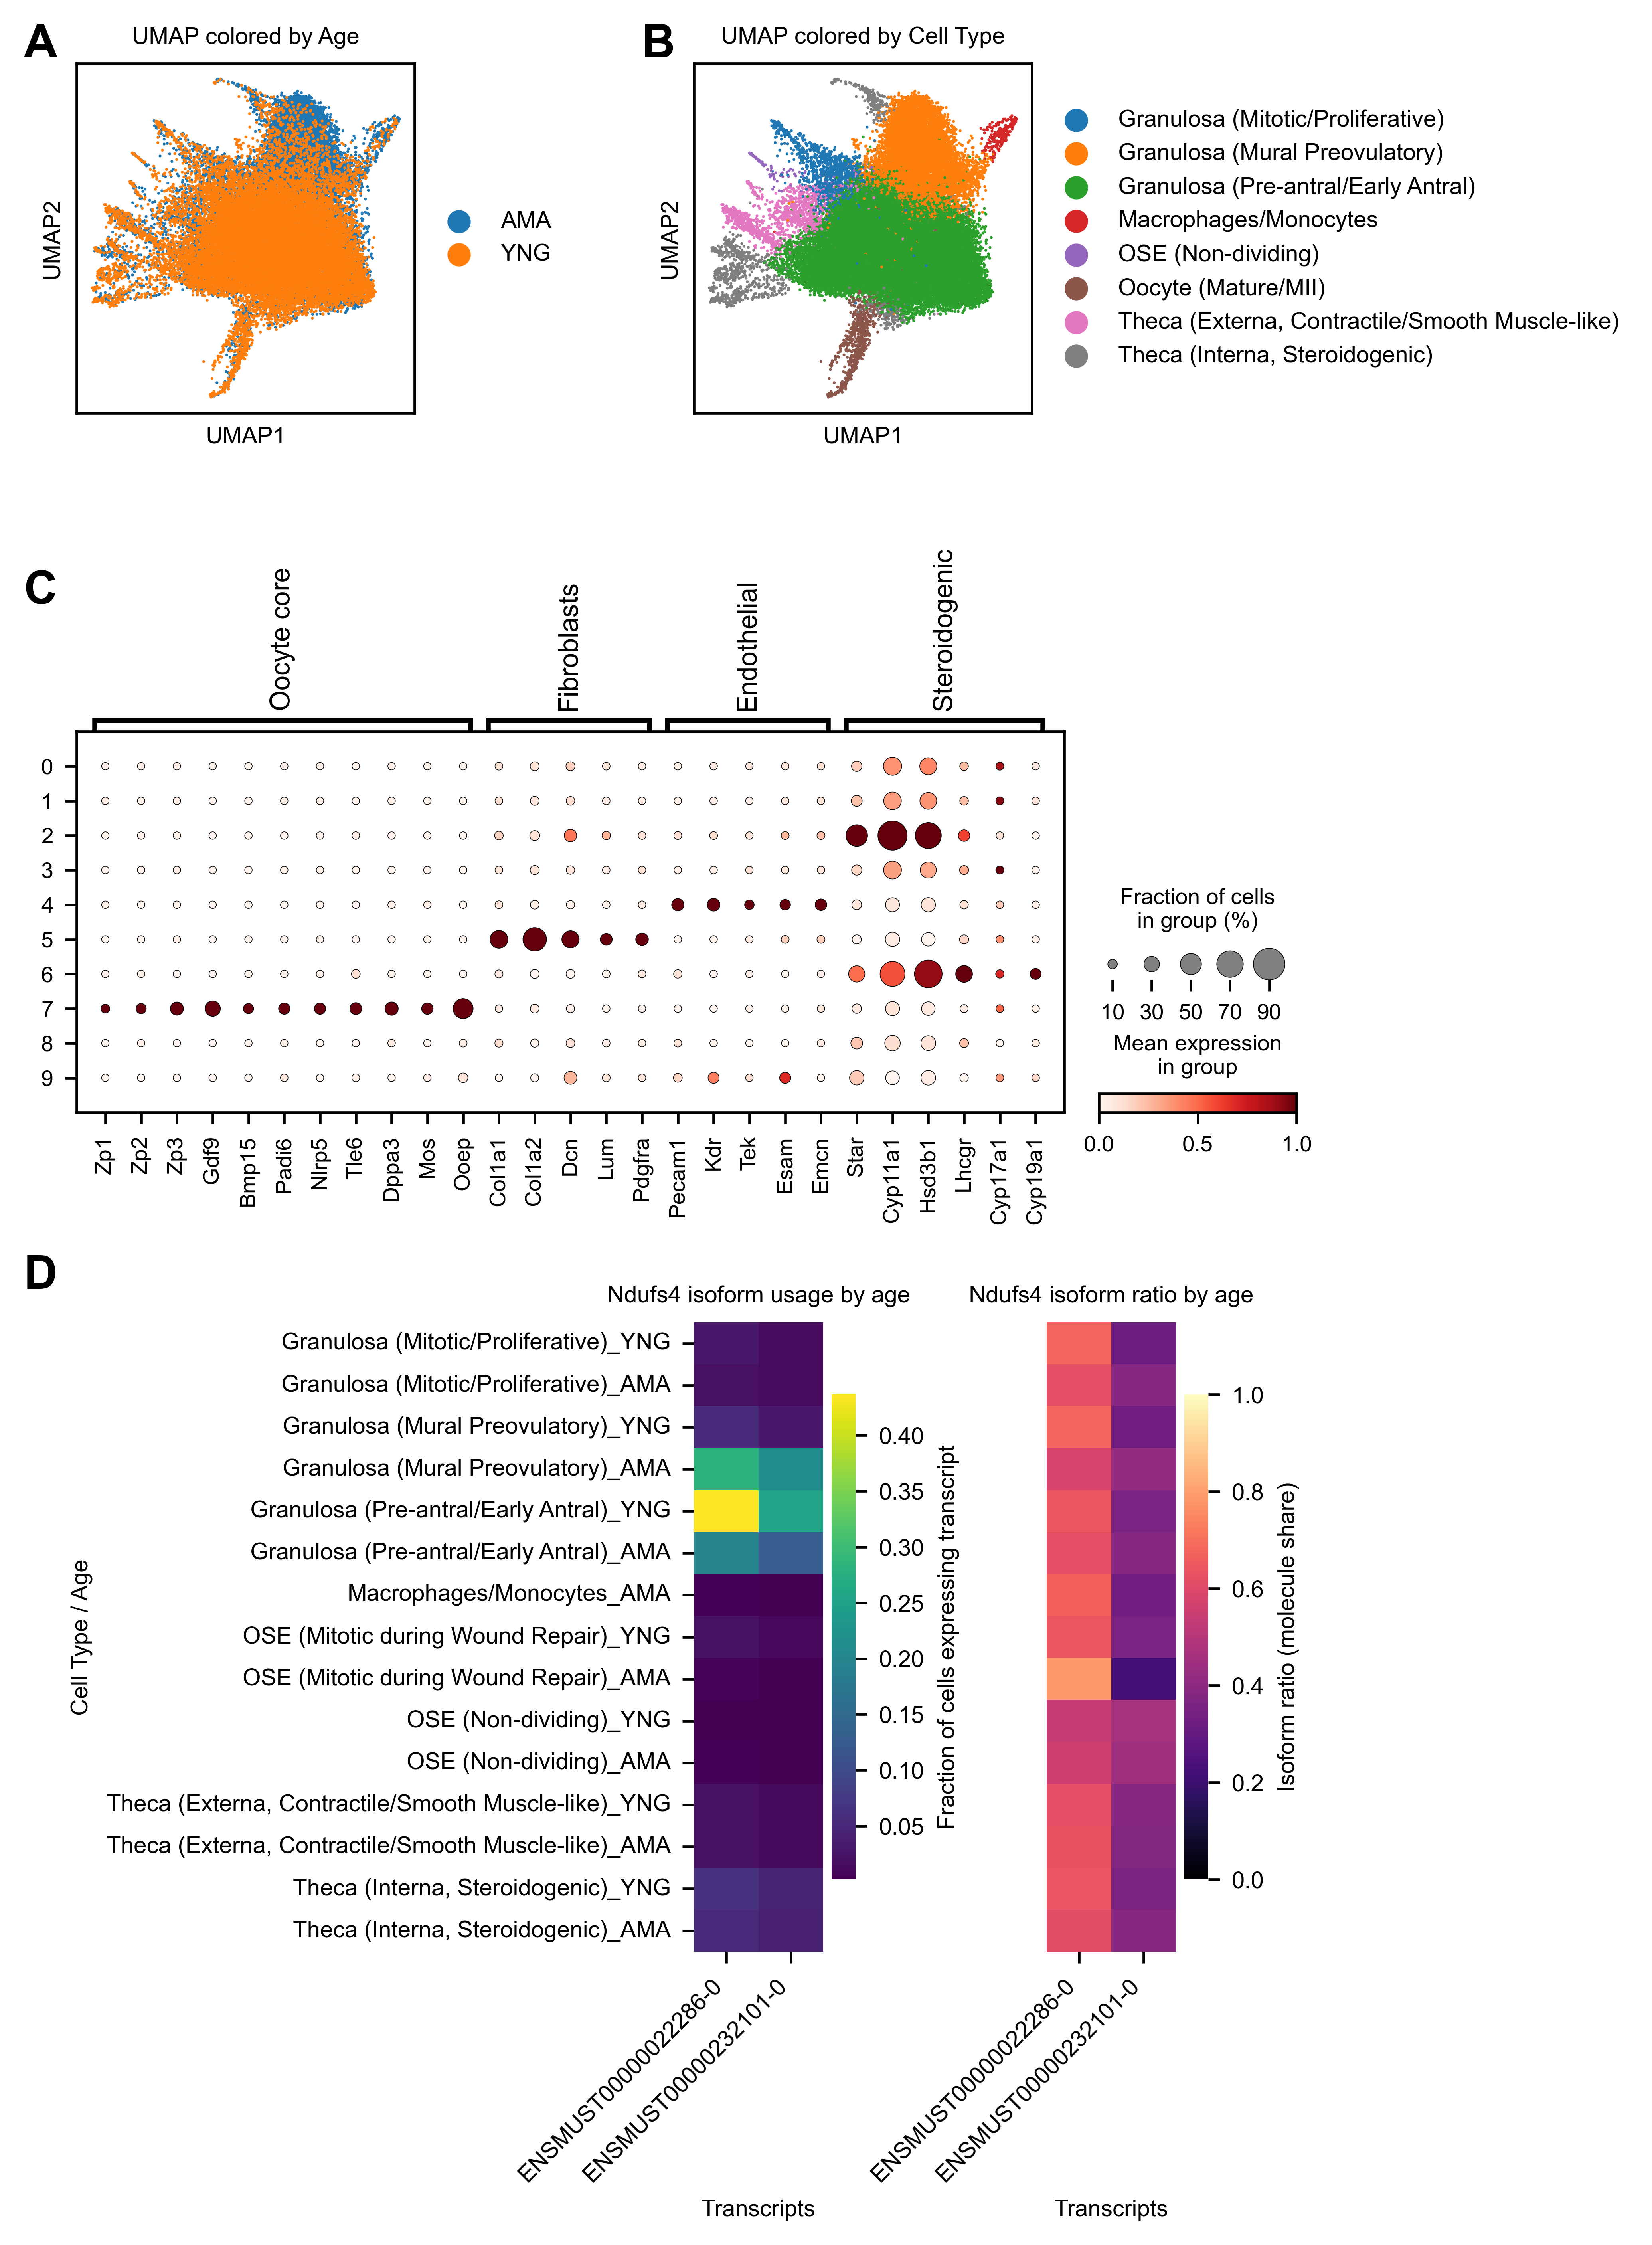

[SupFig4] Saved composite panel to /Users/alvarens/Downloads/Sup_Figure_4/figure_files/Sup_Figure_4_scanpy_gridspec.png


PosixPath('/Users/alvarens/Downloads/Sup_Figure_4/figure_files/Sup_Figure_4_scanpy_gridspec.png')

In [21]:
print("[SupFig4] Building revised gridspec panel with UMAPs, lineage markers, and isoform heatmaps...")

plt.rcParams["font.family"] = "sans-serif"
preferred_fonts = ["Arial", "DejaVu Sans", "Liberation Sans"]
existing_fonts = plt.rcParams.get("font.sans-serif", [])
plt.rcParams["font.sans-serif"] = preferred_fonts + [f for f in existing_fonts if f not in preferred_fonts]
plt.rcParams["font.size"] = 8
plt.rcParams["axes.titlesize"] = 7
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["legend.fontsize"] = 7
plt.rcParams.update({
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    #"cbar.ticklocation": "right",  # optional tweak
})


def sort_celltype_age(values, ages):
    age_order = list(dict.fromkeys(ages))

    def key(entry):
        if "_" in entry:
            cell_type, age = entry.rsplit("_", 1)
            try:
                idx = age_order.index(age)
            except ValueError:
                idx = len(age_order)
            return (cell_type, idx)
        return (entry, len(age_order))

    return sorted(values, key=key)

def prepare_age_order(adata):
    age_series = adata.obs["Age"].astype(str)
    observed = list(dict.fromkeys(age_series))
    preferred = ["YNG", "AMA"]
    ordered = [age for age in preferred if age in observed]
    ordered.extend([age for age in observed if age not in ordered])
    return ordered

def place_panel_label(fig, ax, label, x_pad=-0.01, y_pad=0.015):
    bbox = ax.get_position()
    fig.text(
        bbox.x0 + x_pad,
        bbox.y1 + y_pad,
        label,
        fontsize=14,
        fontweight="bold",
        ha="right",
        va="top",
    )

combined_counts_path = DATA_DIR / scanpy_config.combined_counts_filename
ratio_path = DATA_DIR / scanpy_config.isoform_group_ratio_filename
annotation_path = DATA_DIR / scanpy_config.splice_annotation_filename
if 'scanpy_outputs' not in globals():
    raise RuntimeError('scanpy_outputs not initialized; run the data prep cell first.')

adata_full = scanpy_outputs.adata_full
combined_counts = scanpy_outputs.combined_isoform_counts.copy()
isoform_group_ratios = scanpy_outputs.isoform_group_ratios.copy()
if isoform_group_ratios.empty and ratio_path.exists():
    isoform_group_ratios = pd.read_csv(ratio_path)
if combined_counts.empty and combined_counts_path.exists():
    combined_counts = pd.read_csv(combined_counts_path)
age_order = prepare_age_order(adata_full)

fig = plt.figure(figsize=(8, 11), dpi=600)
gs = gridspec.GridSpec(
    15,
    17,
    height_ratios=[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    hspace=1.0,
    wspace=0.2,
    figure=fig,
)

ax_age = fig.add_subplot(gs[0:3, 0:4])
ax_celltype = fig.add_subplot(gs[0:3, 7:11])
ax_dot = fig.add_subplot(gs[4:8, 0:14])
ax_heat_fraction = fig.add_subplot(gs[9:14, 7:9])
ax_heat_ratio = fig.add_subplot(gs[9:14, 11:13])
# ax_heat_groups = fig.add_subplot(gs[6:10, 9:16])

sc.pl.umap(
    adata_full,
    color="Age",
    ax=ax_age,
    show=False,
    legend_loc="right margin",
    legend_fontsize=7,
)
ax_age.set_title("UMAP colored by Age")

sc.pl.umap(
    adata_full,
    color="Cell Type",
    ax=ax_celltype,
    show=False,
    legend_loc="right margin",
    legend_fontsize=7,
)
ax_celltype.set_title("UMAP colored by Cell Type")

focus_sets = {
    "Oocyte core": ["Zp1", "Zp2", "Zp3", "Gdf9", "Bmp15", "Padi6", "Nlrp5", "Tle6", "Dppa3", "Mos", "WEE2", "Ooep"],
    "Fibroblasts": ["Col1a1", "Col1a2", "Dcn", "Lum", "Pdgfra"],
    "Endothelial": ["Pecam1", "Kdr", "Tek", "Esam", "Emcn"],
    "Steroidogenic": ["Star", "Cyp11a1", "Hsd3b1", "Lhcgr", "Cyp17a1", "Cyp19a1"],
}
focus_panels = {k: [g for g in genes if g in adata_full.var_names] for k, genes in focus_sets.items()}
focus_panels = {k: v for k, v in focus_panels.items() if v}
dotplot_min_figure_height = 2.5  # controls legend stack height
dotplot_legend_width = 2  # shrinks legend column inside gridspec
if not focus_panels:
    ax_dot.text(0.5, 0.5, "Requested marker sets not detected", ha="center", va="center")
    ax_dot.axis("off")
else:
    dp = sc.pl.dotplot(
        adata_full,
        var_names=focus_panels,
        groupby="leiden",
        standard_scale="var",
        dendrogram=False,
        ax=ax_dot,
        show=False,
        return_fig=True,
        #title="Focused marker sanity check",
    )
    dp.min_figure_height = dotplot_min_figure_height
    dp.legend(width=dotplot_legend_width, show_size_legend=True, show_colorbar=True)
    dp.style(cmap="Reds",smallest_dot=5, largest_dot=90)
    dp.make_figure()

transcripts_of_interest = ["ENSMUST00000022286-0", "ENSMUST00000232101-0"]
row_sorter = lambda labels: sort_celltype_age(labels, age_order)

plot_isoform_fraction_heatmap(
    ax_heat_fraction,
    combined_counts,
    transcripts=transcripts_of_interest,
    sorter=row_sorter,
    title="Ndufs4 isoform usage by age",
    ylabel="Cell Type / Age",
    show_y_ticks=True,
)

plot_isoform_ratio_heatmap(
    ax_heat_ratio,
    isoform_group_ratios,
    combined_counts=combined_counts,
    transcripts=transcripts_of_interest,
    sorter=row_sorter,
    title="Ndufs4 isoform ratio by age",
    show_y_ticks=False,
)

summary_df = None
if "outputs" in globals():
    summary_df = getattr(outputs, "summary", None)
if summary_df is None or summary_df.empty:
    summary_path = FIGURE_DIR / "Sup_Figure_4_last300_events_summary_with_uniqueness.csv"
    if summary_path.exists():
        summary_df = pd.read_csv(summary_path)


# promoter_meta = None
# if summary_df is not None and not summary_df.empty:
#     promoter_meta = summary_df[["transcript_id", "promoter_group"]].copy()

# plot_promoter_group_heatmap(
#     ax_heat_groups,
#     combined_counts,
#     promoter_meta,
#     sorter=row_sorter,
# )

place_panel_label(fig, ax_age, "A")
place_panel_label(fig, ax_celltype, "B")
place_panel_label(fig, ax_dot, "C", y_pad=0.02)
place_panel_label(fig, ax_dot, "D", y_pad=-0.24)
# place_panel_label(fig, ax_heat_groups, "E")

#plt.subplots_adjust(top=0.97, bottom=0.06, left=0.08, right=0.99)

final_panel_path = FIGURE_DIR / "Sup_Figure_4_scanpy_gridspec.png"
fig.savefig(final_panel_path, dpi=600)
plt.show()

plt.close(fig)
print(f"[SupFig4] Saved composite panel to {final_panel_path}")
final_panel_path









